In [8]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

from sarimax import plot_target
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pmdarima.arima import auto_arima

from sarima import plot_target
from sarima import multitarget_sarima

import itertools
from tqdm.auto import tqdm


import os

In [9]:
LABEL_COLS  = ['Tax Revenues', 'BIR','BOC','Other Offices', 'Expenditures']
START_DATES = ["2000-01-01"]
FEATURE_CONFIGS = {
    'Tax Revenues': {
        "tag":          "feat_select",
        "features":     ['BIR', 'Imports_PHPMN', 'Other Offices', 'Non-tax Revenues', 'USDPHP', 'Inflation'],
        "dummy_vars":   ['TRAIN', 'CREATE', 'COVID-19'],
        "use_seasonal": True,
        "lag_periods":  [],
        "use_lags":     False,
    },
    'BIR': {
        "tag":          "feat_select",
        "features":     ['Tax Revenues', 'Imports_PHPMN', 'Other Offices', 'USDPHP', 'Non-tax Revenues', 'Inflation'],
        "dummy_vars":   ['TRAIN', 'CREATE', 'COVID-19'],
        "use_seasonal": True,
        "lag_periods":  [],
        "use_lags":     False,
    },
    'BOC': {
        "tag":          "feat_select",
        "features":     ['Imports_PHPMN', 'Other Offices', 'USDPHP', 'Non-tax Revenues'],
        "dummy_vars":   ['TRAIN', 'CREATE', 'COVID-19'],
        "use_seasonal": True,
        "lag_periods":  [1],
        "use_lags":     True,
    },
    'Other Offices': {
        "tag":          "feat_select",
        "features":     ['Pop_disagg','Imports_PHPMN', 'Non-tax Revenues', 'USDPHP'],
        "dummy_vars":   ['TRAIN', 'CREATE', 'COVID-19'],
        "use_seasonal": True,
        "lag_periods":  [1,3,6, 12],
        "use_lags":     True,
    },
    'Expenditures': {
        "tag":          "feat_select",
        "features":     ['Imports_PHPMN','Non-tax Revenues', 'USDPHP', 'Inflation'],
        "dummy_vars":   ['TRAIN', 'CREATE', 'COVID-19'],
        "use_seasonal": True,
        "lag_periods":  [12],
        "use_lags":     True,
    },
}

## From 1992

In [10]:
#Prepare data
from pathlib import Path

data_dir = Path.cwd() / "Data"
cordata = pd.read_csv(data_dir / "cordata.csv")
macro = pd.read_csv(data_dir / "disaggregated.csv")
dummy = pd.read_csv(data_dir / "dummy.csv")

macro = macro.rename(columns = {"Unnamed: 3": "Date"})
features = pd.merge(macro, dummy, on="Date", how="left")
dummy_cols = [c for c in dummy.columns if c != "Date"]
features[dummy_cols] = features[dummy_cols].fillna(0)

target = cordata[["Date", "BIR", "BOC", "Other Offices", "Non-tax Revenues", "Expenditures"]]
features = features[["Date", "Inflation", "Imports", "Exports", "USDPHP", "NominalGDP_disagg", "Pop_disagg", 
                     "COVID-19", "TRAIN","CREATE","FIST","BIR_COMM"]]
target["Tax Revenues"] = target[["BIR", "BOC", "Other Offices"]].sum(axis=1)

# Convert Date to datetime
target["Date"] = pd.to_datetime(target["Date"])
features["Date"] = pd.to_datetime(features["Date"] )

# Filter both to start from 1992-01-01
target = target[target["Date"] >= "1992-01-01"]
features = features[features["Date"] >= "1992-01-01"]

target = target.set_index("Date")
features = features.set_index("Date")

# Replace NaN values with 0
features = features.fillna(0)

In [11]:
# Split data
test_num = int(len(target) * 0.20)
train_size = len(target) - test_num

train = target[:train_size]
test = target[train_size:]

test_num = int(len(target) * 0.20)
train_size = len(target) - test_num

feat_train = features[:train_size]
feat_test = features[train_size:]


In [12]:
records = []

for x in TARGETS["disaggregated"]["labels"]:
    level = adfuller(train[x].dropna())
    first_diff = adfuller(train[x].diff().dropna())
    second_diff = adfuller(train[x].diff().diff().dropna())
    seasonal_diff = adfuller(train[x].diff(12).dropna())           # D=1, s=12
    seasonal_double_diff = adfuller(train[x].diff().diff(12).dropna())  # d=1, D=1, s=12

    records.append({
        'Variable': x,
        'Level p-value': round(level[1], 4),
        'Level Stationary': level[1] < 0.05,
        'First Diff p-value': round(first_diff[1], 4),
        'First Diff Stationary': first_diff[1] < 0.05,
        'Second Diff p-value': round(second_diff[1], 4),
        'Second Diff Stationary': second_diff[1] < 0.05,
        'Seasonal Diff p-value': round(seasonal_diff[1], 4),
        'Seasonal Diff Stationary': seasonal_diff[1] < 0.05,
        'Seasonal Double Diff p-value': round(seasonal_double_diff[1], 4),
        'Seasonal Double Diff Stationary': seasonal_double_diff[1] < 0.05,
    })

pd.DataFrame(records).set_index('Variable')

NameError: name 'TARGETS' is not defined

### Order Specification

In [ ]:
diff_tax_train = train["Tax Revenues"].diff().diff().dropna()
diff_BIR_train = train["BIR"].diff().diff().dropna()
diff_BOC_train = train["BOC"].diff().dropna()
diff_other_offices_train = train["Other Offices"].diff().dropna()
diff_expenditure_train = train['Expenditures'].diff().dropna()

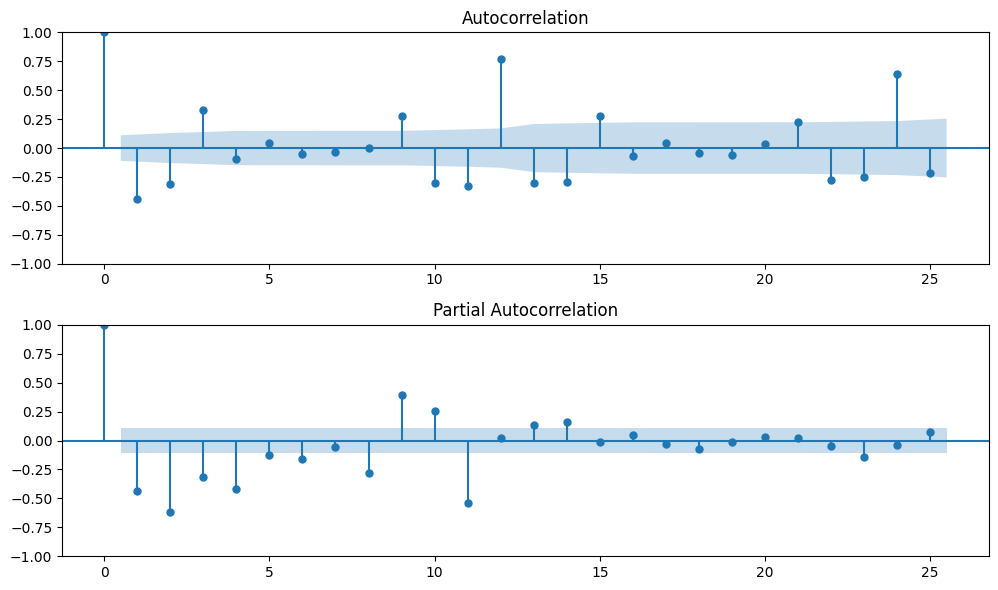

In [ ]:
#Tax
fig, ax = plt.subplots(2, 1, figsize=(10,6))
plot_acf((diff_tax_train).dropna(), ax=ax[0])
plot_pacf((diff_tax_train).dropna(), ax=ax[1])
plt.tight_layout()
plt.show()

# max p = 4 max q = 3 max d = 2 max D = 1 max Q = 2 max P = 1

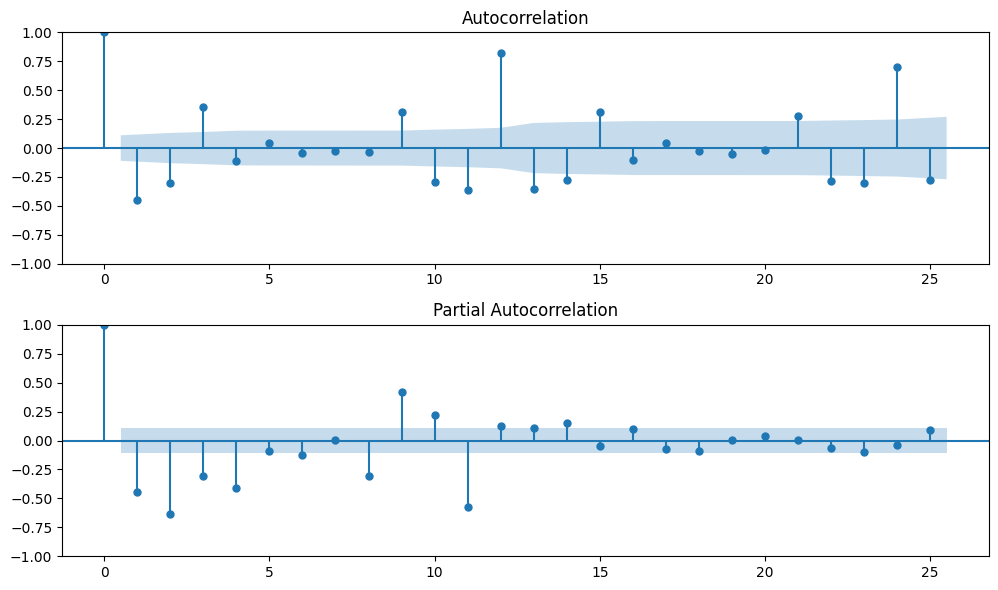

In [ ]:
#BIR
fig, ax = plt.subplots(2, 1, figsize=(10,6))
plot_acf((diff_BIR_train).dropna(), ax=ax[0])
plot_pacf((diff_BIR_train).dropna(), ax=ax[1])
plt.tight_layout()
plt.show()

# max p = 4 max q = 3 max d = 2 max D = 1 max Q = 2 max P = 1

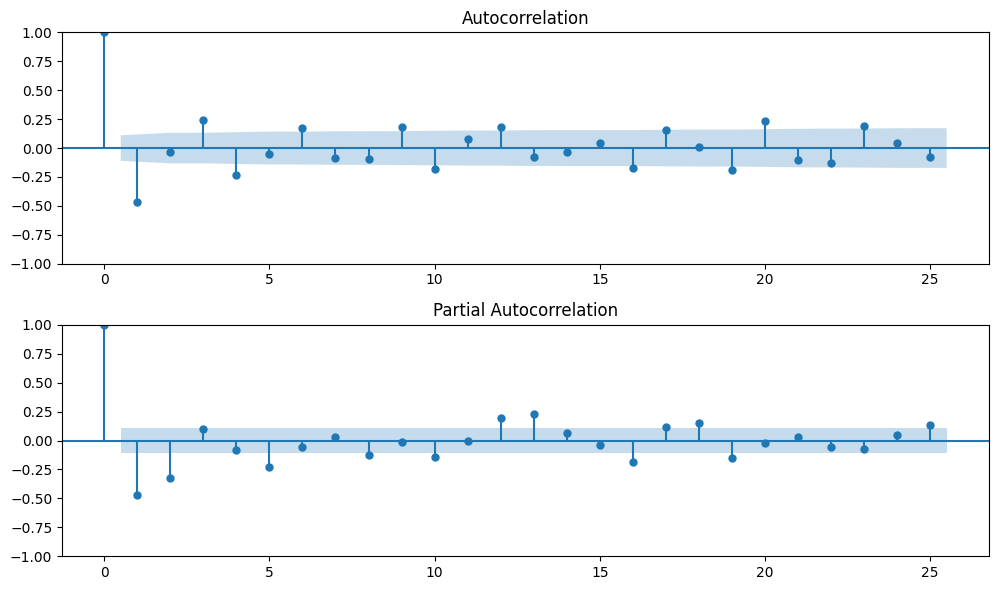

In [ ]:
#BOC
fig, ax = plt.subplots(2, 1, figsize=(10,6))
plot_acf((diff_BOC_train).dropna(), ax=ax[0])
plot_pacf((diff_BOC_train).dropna(), ax=ax[1])
plt.tight_layout()
plt.show()

# max p = 2 max q = 3 max d = 1 max D = 1 max Q = 0 max P = 1

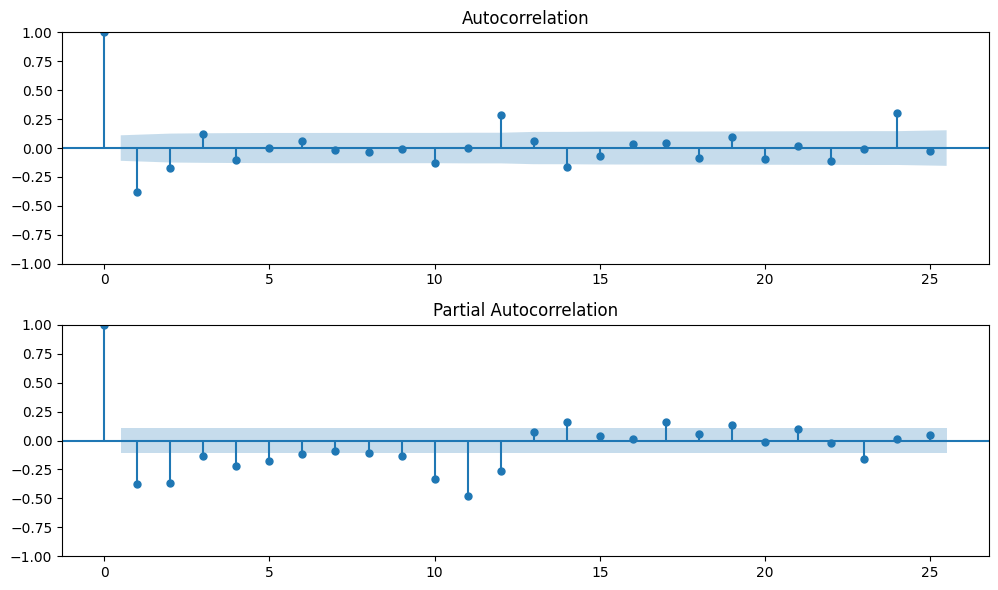

In [ ]:
#Other Offices
fig, ax = plt.subplots(2, 1, figsize=(10,6))
plot_acf((diff_other_offices_train).dropna(), ax=ax[0])
plot_pacf((diff_other_offices_train).dropna(), ax=ax[1])
plt.tight_layout()
plt.show()

# max p = 6 max q = 2 max d = 1 max D = 1 max Q = 2 max P = 1

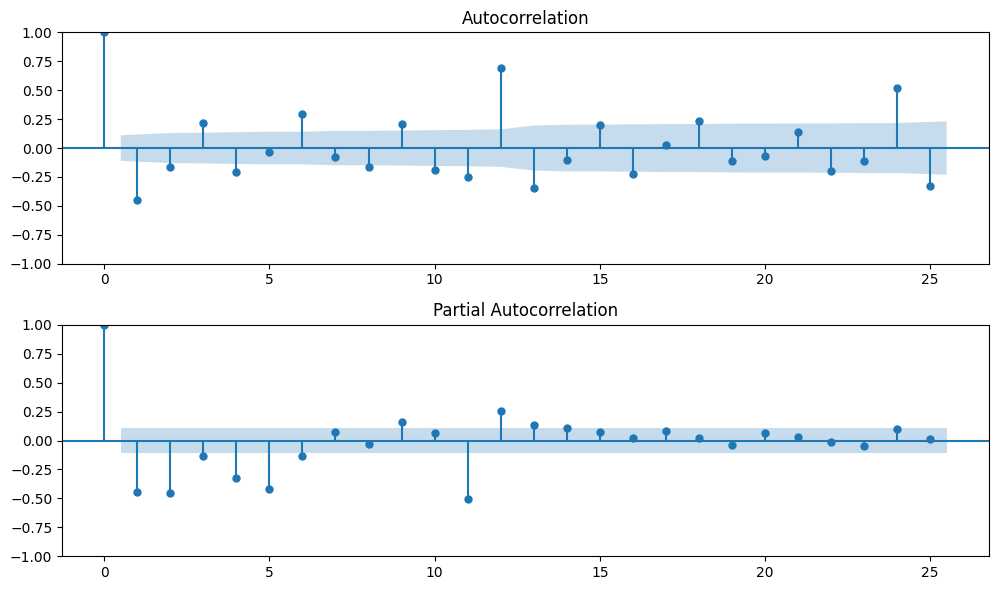

In [ ]:
#Expenditures Train
fig, ax = plt.subplots(2, 1, figsize=(10,6))
plot_acf((diff_expenditure_train).dropna(), ax=ax[0])
plot_pacf((diff_expenditure_train).dropna(), ax=ax[1])
plt.tight_layout()
plt.show()

# max p = 6 max q = 4 max d = 1 max D = 1 max Q = 2 max P = 1

In [ ]:
tax_train = train["Tax Revenues"]
bir_train = train["BIR"]
boc_train = train["BOC"]
others_train = train["Other Offices"]
expenditure_train = train['Expenditures']
tax_test = test["Tax Revenues"]
bir_test = test["BIR"]
boc_test = test["BOC"]
others_test = test["Other Offices"]
expenditure_test = test['Expenditures']

In [ ]:
macro_train = feat_train[["Imports","Exports", "NominalGDP_disagg", "Pop_disagg", "USDPHP", "COVID-19", "TRAIN", "CREATE", "FIST", "BIR_COMM"]]
macro_test = feat_test[["Imports","Exports", "NominalGDP_disagg", "Pop_disagg", "USDPHP", "COVID-19", "TRAIN", "CREATE", "FIST", "BIR_COMM"]]

In [ ]:
labels = TARGETS["disaggregated"]["labels"]

bounds_map = {
    "Tax Revenues":    {"p_min": 0, "p_max": 4, "d_min": 1, "d_max": 2, "q_min": 0, "q_max": 3, "P_min": 0, "P_max": 1, "D_min": 1, "D_max": 1, "Q_min": 0, "Q_max": 2},
    "BIR":             {"p_min": 0, "p_max": 4, "d_min": 1, "d_max": 2, "q_min": 0, "q_max": 3, "P_min": 0, "P_max": 1, "D_min": 1, "D_max": 1, "Q_min": 0, "Q_max": 2},
    "BOC":             {"p_min": 0, "p_max": 2, "d_min": 1, "d_max": 1, "q_min": 0, "q_max": 3, "P_min": 0, "P_max": 1, "D_min": 1, "D_max": 1, "Q_min": 0, "Q_max": 0},
    "Other Offices":   {"p_min": 0, "p_max": 6, "d_min": 1, "d_max": 1, "q_min": 0, "q_max": 2, "P_min": 0, "P_max": 1, "D_min": 0, "D_max": 1, "Q_min": 0, "Q_max": 2},
    "Expenditures":    {"p_min": 0, "p_max": 6, "d_min": 1, "d_max": 1, "q_min": 0, "q_max": 4, "P_min": 0, "P_max": 1, "D_min": 0, "D_max": 1, "Q_min": 0, "Q_max": 2},
}

best_models_df, all_trials_df, forecasts_df, fitted_models = multitarget_sarima(
    train_df=train,
    test_df=test,
    exog_train=macro_train,
    exog_test=macro_test,
    labels=labels,
    bounds_map=bounds_map,
    seasonal_period=12,
    verbose=True,
    n_jobs=  max(1, (os.cpu_count() or 2) - 1)
    )

display(best_models_df)
display(forecasts_df.head())
os.makedirs("results", exist_ok=True)
forecasts_df.to_csv(os.path.join("results", "sarimax_forecasts.csv"), index=False)

[Tax Revenues] candidates: 240
[BIR] candidates: 240
[BOC] candidates: 24
[Other Offices] candidates: 252
[Expenditures] candidates: 420


Labels completed:   0%|          | 0/5 [00:00<?, ?it/s]

[BOC] done: 24/24, converged=24


Labels completed:  20%|██        | 1/5 [06:00<24:00, 360.24s/it]

[Other Offices] progress: 50/252
[Expenditures] progress: 50/420
[Tax Revenues] progress: 50/240
[BIR] progress: 50/240
[Other Offices] progress: 100/252
[Expenditures] progress: 100/420
[Tax Revenues] progress: 100/240
[BIR] progress: 100/240
[Other Offices] progress: 150/252
[Expenditures] progress: 150/420
[Tax Revenues] progress: 150/240
[BIR] progress: 150/240
[Other Offices] progress: 200/252
[Expenditures] progress: 200/420
[Tax Revenues] progress: 200/240
[BIR] progress: 200/240
[Other Offices] progress: 250/252
[Other Offices] done: 252/252, converged=252


...

Labels completed:  80%|████████  | 4/5 [3:40:34<44:30, 2670.61s/it]  

[Expenditures] progress: 250/420
[Expenditures] progress: 300/420
[Expenditures] progress: 350/420
[Expenditures] progress: 400/420


[Expenditures] done: 420/420, converged=420


,Best_Order,Best_Seasonal_Order,Best_AIC,MAE,RMSE,MAPE_pct
Target,,,,,,
BOC,"(2, 1, 0)","(1, 1, 0, 12)",5349.968882,15220.179237,17383.885347,25.460046
Other Offices,"(2, 1, 2)","(0, 1, 2, 12)",3797.441563,502.109979,656.317819,30.349757
BIR,"(1, 1, 3)","(1, 1, 2, 12)",5524.173755,41358.436877,49715.145037,24.068431
Tax Revenues,"(2, 2, 3)","(1, 1, 2, 12)",5637.085289,68430.249494,82958.555262,29.185087
Expenditures,"(2, 1, 4)","(0, 1, 2, 12)",6007.711661,58982.826227,77189.705864,13.685349


,BOC,Other Offices,BIR,Tax Revenues,Expenditures
Date,,,,,
2018-06-01,50034.546918,2054.327334,155167.202006,206444.384547,310827.577489
2018-07-01,50212.357293,1973.829527,166181.854143,224232.357801,294103.179012
2018-08-01,51228.141875,2314.739039,189152.100430,238592.403428,240592.140004
2018-09-01,53159.396402,1952.522617,165655.298688,219183.853477,279883.080741
2018-10-01,55631.461595,2075.800509,166357.174856,226908.018209,269649.796990


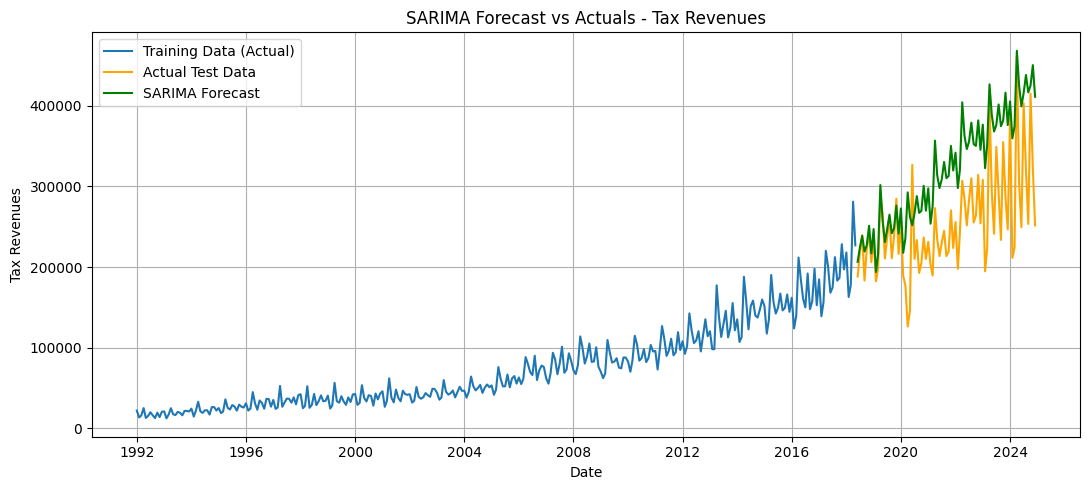

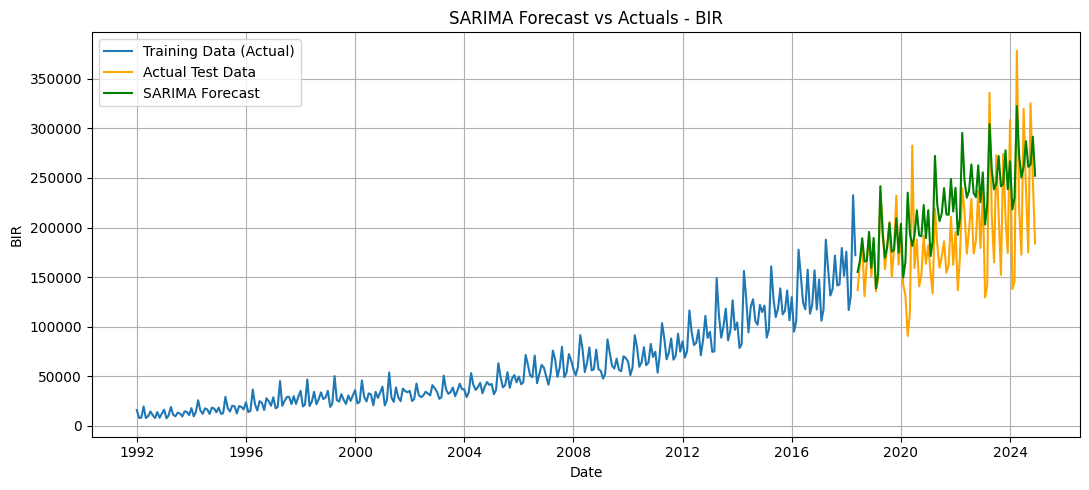

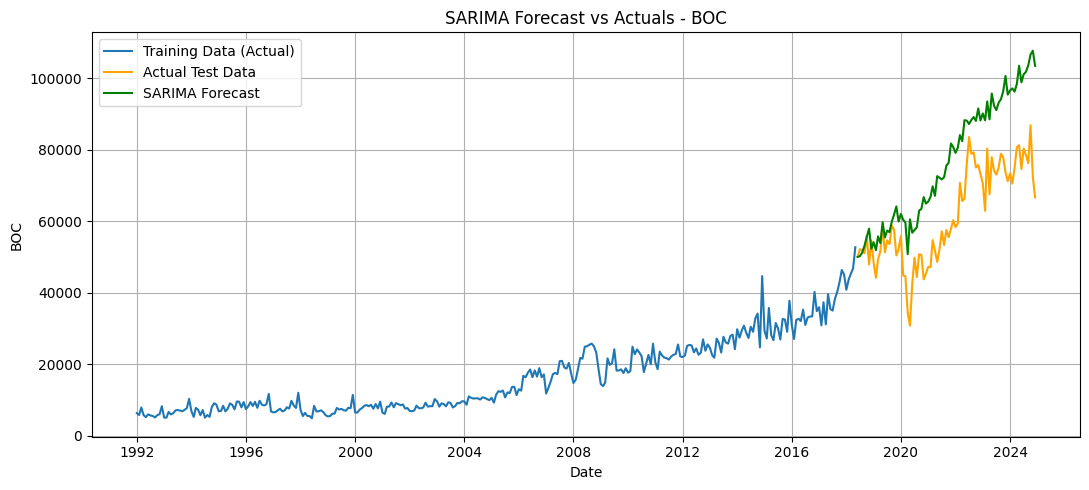

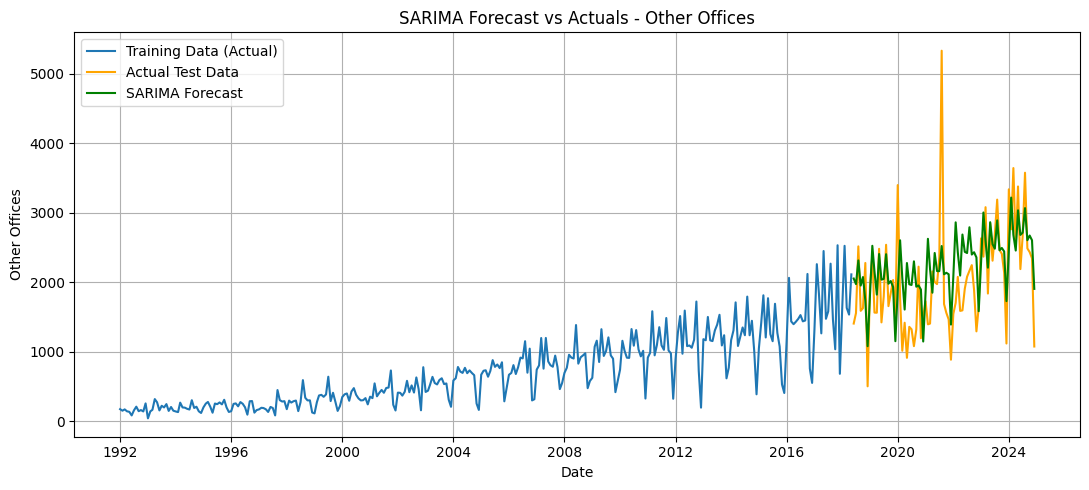

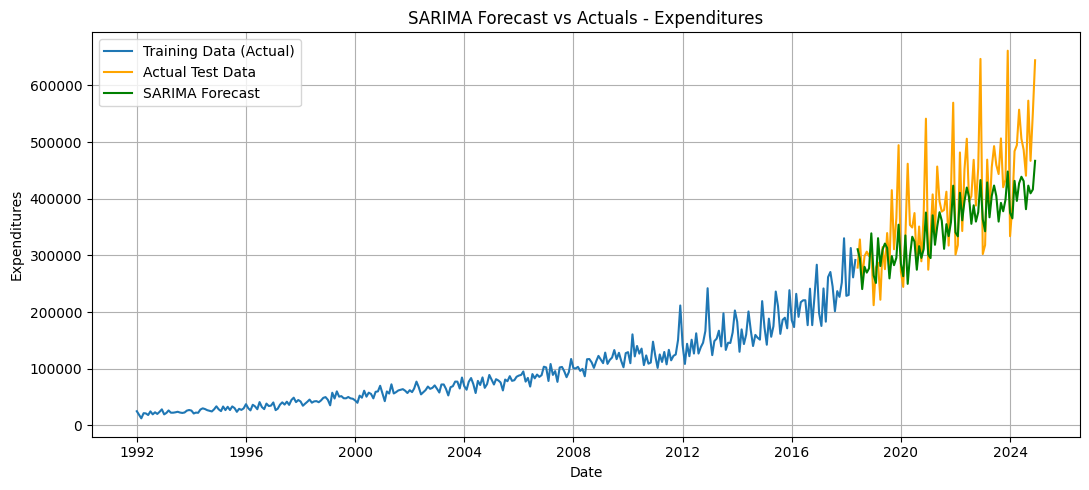

In [ ]:
labels_to_plot = [lbl for lbl in labels if lbl in train.columns and lbl in test.columns and lbl in forecasts_df.columns]

if not labels_to_plot:
    raise ValueError("No matching labels found across train/test/forecasts_df.")

for lbl in labels_to_plot:
    plt.figure(figsize=(11, 5))
    plt.plot(train.index, train[lbl], label="Training Data (Actual)")
    plt.plot(test.index, test[lbl], label="Actual Test Data", color="orange")
    plt.plot(forecasts_df.index, forecasts_df[lbl], label="SARIMA Forecast", color="green")
    plt.title(f"SARIMA Forecast vs Actuals - {lbl}")
    plt.xlabel("Date")
    plt.ylabel(lbl)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## For 2000

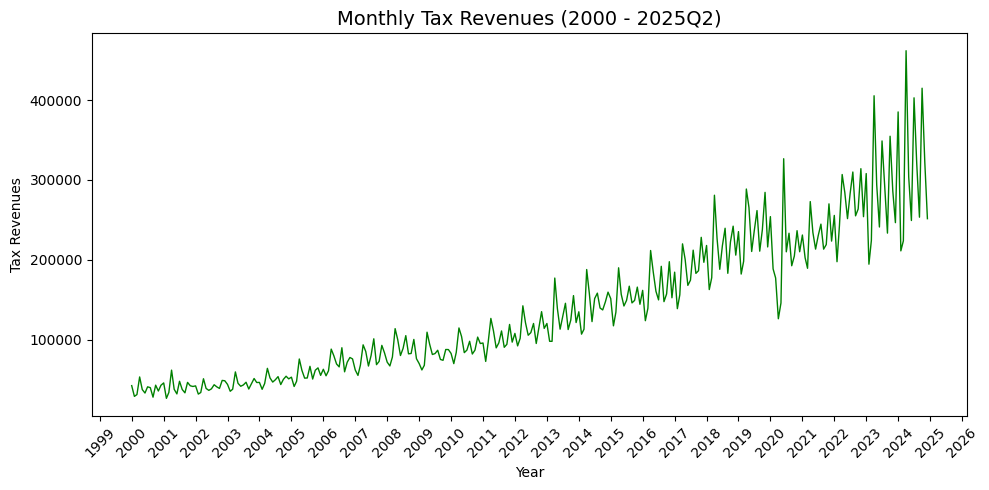

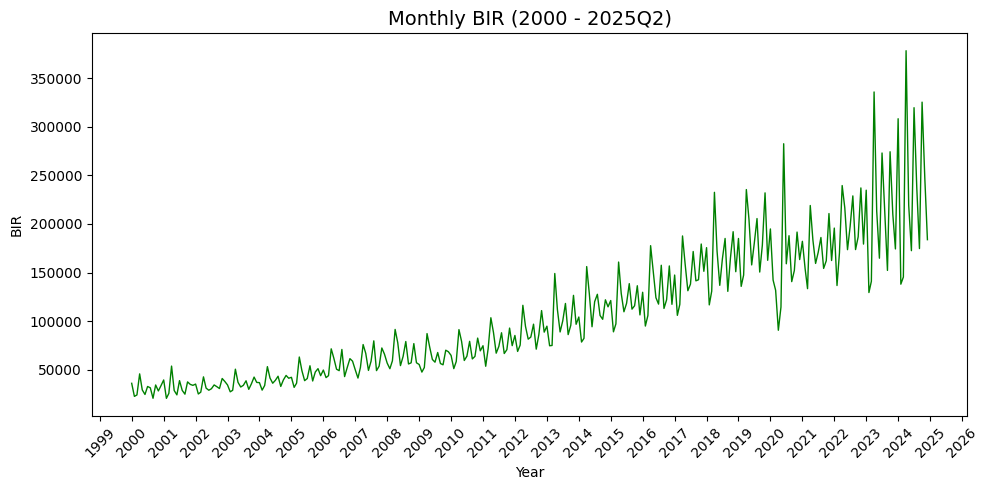

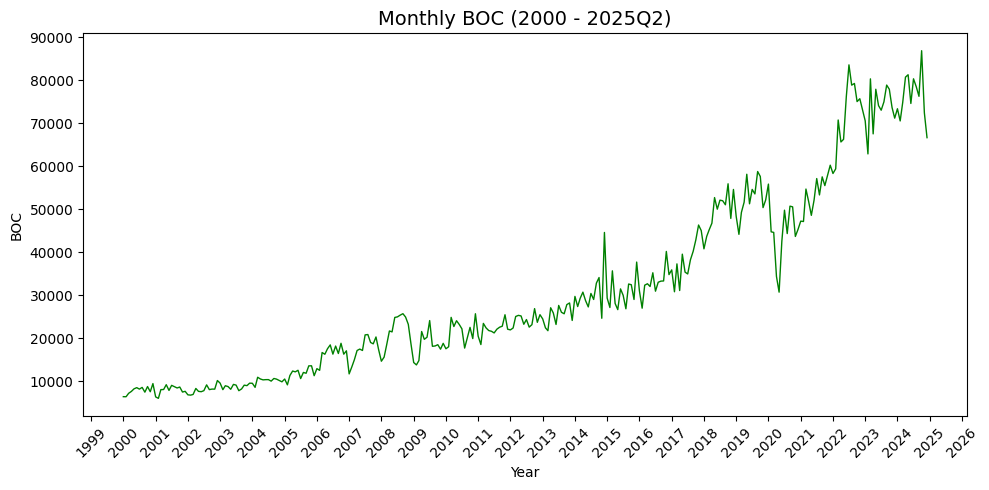

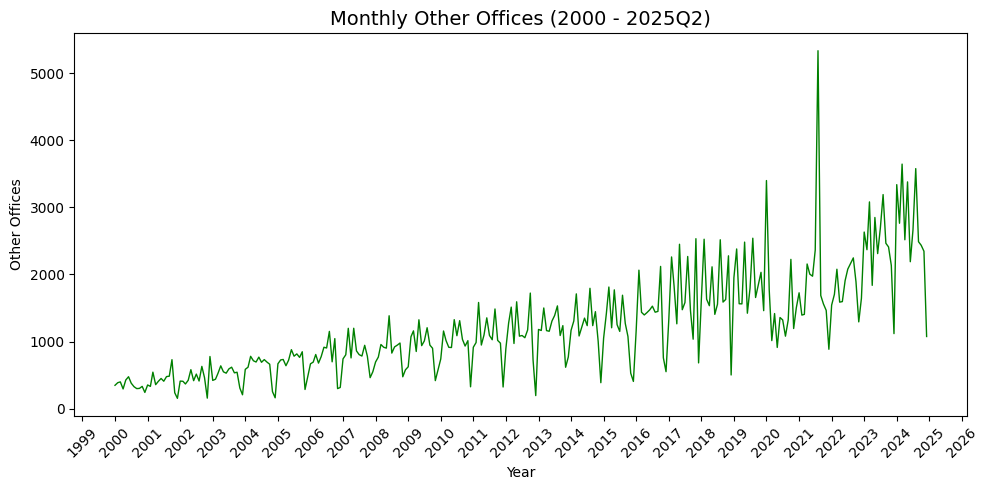

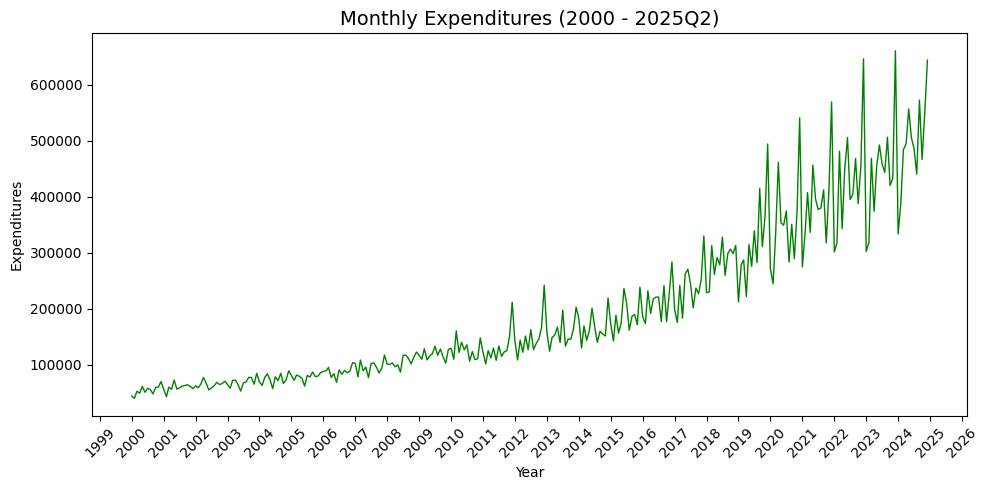

In [13]:
# Prepare data (duplicated from For 1992 section)
from pathlib import Path

data_dir = Path.cwd() / "Data"
cordata = pd.read_csv(data_dir / "cordata.csv")
macro = pd.read_csv(data_dir / "disaggregated.csv")
dummy = pd.read_csv(data_dir / "dummy.csv")

macro = macro.rename(columns={"Unnamed: 3": "Date"})
features = pd.merge(macro, dummy, on="Date", how="left")
dummy_cols = [c for c in dummy.columns if c != "Date"]
features[dummy_cols] = features[dummy_cols].fillna(0)

target = cordata[["Date", "BIR", "BOC", "Other Offices", "Non-tax Revenues", "Expenditures"]]
features = features[["Date", "Inflation", "Imports_PHPMN", "Exports_PHPMN", "USDPHP", "NominalGDP_disagg", "Pop_disagg",
                     "COVID-19", "TRAIN", "CREATE", "FIST", "BIR_COMM"]]
target["Tax Revenues"] = target[["BIR", "BOC", "Other Offices"]].sum(axis=1)

target["Date"] = pd.to_datetime(target["Date"])
features["Date"] = pd.to_datetime(features["Date"])

target = target[target["Date"] >= "2000-01-01"]
features = features[features["Date"] >= "2000-01-01"]

target = target.set_index("Date")
features = features.set_index("Date")
features = features.fillna(0)

for x in LABEL_COLS:
    plot_target(target, x)

test_num = int(len(target) * 0.20)
train_size = len(target) - test_num

train = target[:train_size]
test = target[train_size:]

test_num = int(len(target) * 0.20)
train_size = len(target) - test_num

feat_train = features[:train_size]
feat_test = features[train_size:]

records = []



In [14]:
for x in LABEL_COLS:
    level = adfuller(train[x].dropna())
    first_diff = adfuller(train[x].diff().dropna())
    second_diff = adfuller(train[x].diff().diff().dropna())
    seasonal_diff = adfuller(train[x].diff(12).dropna())
    seasonal_double_diff = adfuller(train[x].diff().diff(12).dropna())

    records.append({
        "Variable": x,
        "Level p-value": round(level[1], 4),
        "Level Stationary": level[1] < 0.05,
        "First Diff p-value": round(first_diff[1], 4),
        "First Diff Stationary": first_diff[1] < 0.05,
        "Second Diff p-value": round(second_diff[1], 4),
        "Second Diff Stationary": second_diff[1] < 0.05,
        "Seasonal Diff p-value": round(seasonal_diff[1], 4),
        "Seasonal Diff Stationary": seasonal_diff[1] < 0.05,
        "Seasonal Double Diff p-value": round(seasonal_double_diff[1], 4),
        "Seasonal Double Diff Stationary": seasonal_double_diff[1] < 0.05,
    })

pd.DataFrame(records).set_index("Variable")


,Level p-value,Level Stationary,First Diff p-value,First Diff Stationary,Second Diff p-value,Second Diff Stationary,Seasonal Diff p-value,Seasonal Diff Stationary,Seasonal Double Diff p-value,Seasonal Double Diff Stationary
Variable,,,,,,,,,,
Tax Revenues,1.0000,False,0.1019,False,0.0,True,0.5032,False,0.0,True
BIR,1.0000,False,0.0977,False,0.0,True,0.6459,False,0.0,True
BOC,0.9954,False,0.0004,True,0.0,True,0.0773,False,0.0,True
Other Offices,0.9967,False,0.0000,True,0.0,True,0.0003,True,0.0,True
Expenditures,1.0000,False,0.0084,True,0.0,True,0.8343,False,0.0,True


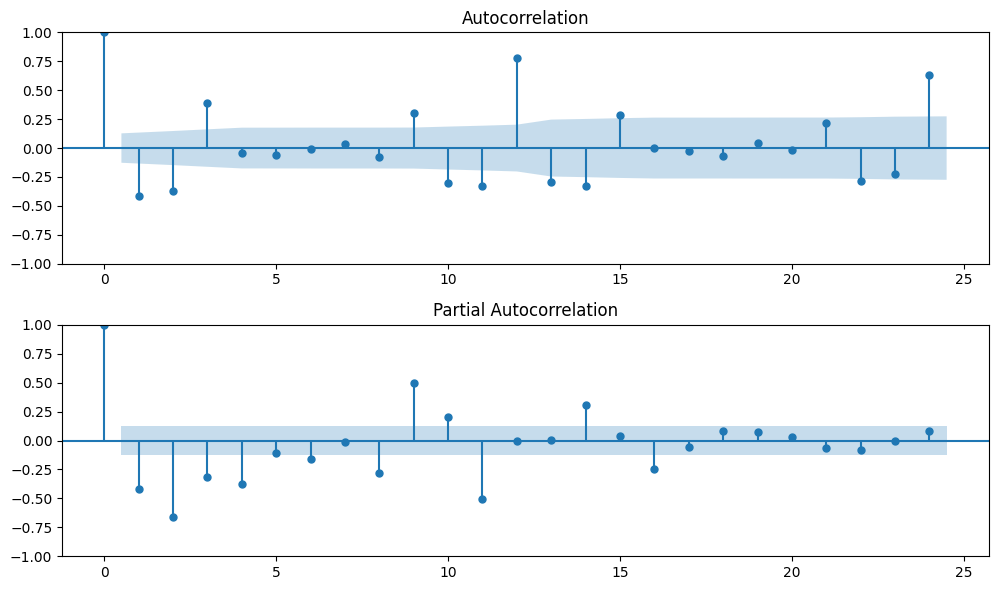

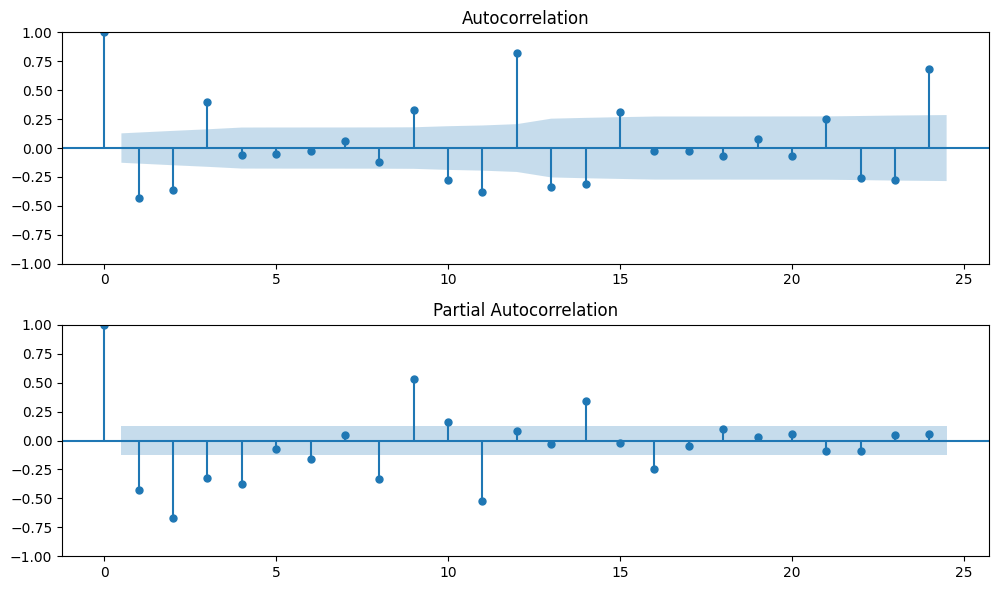

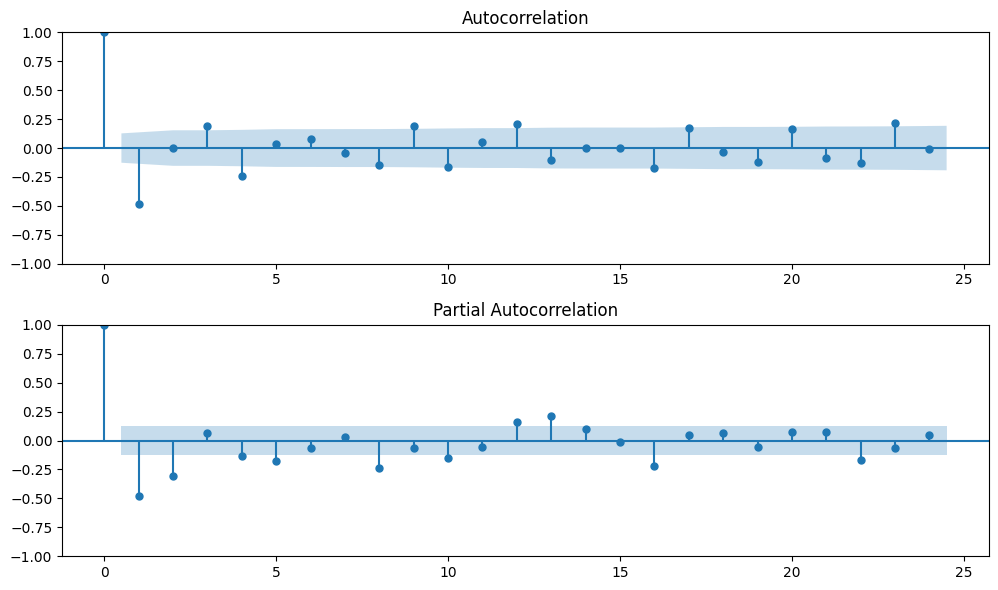

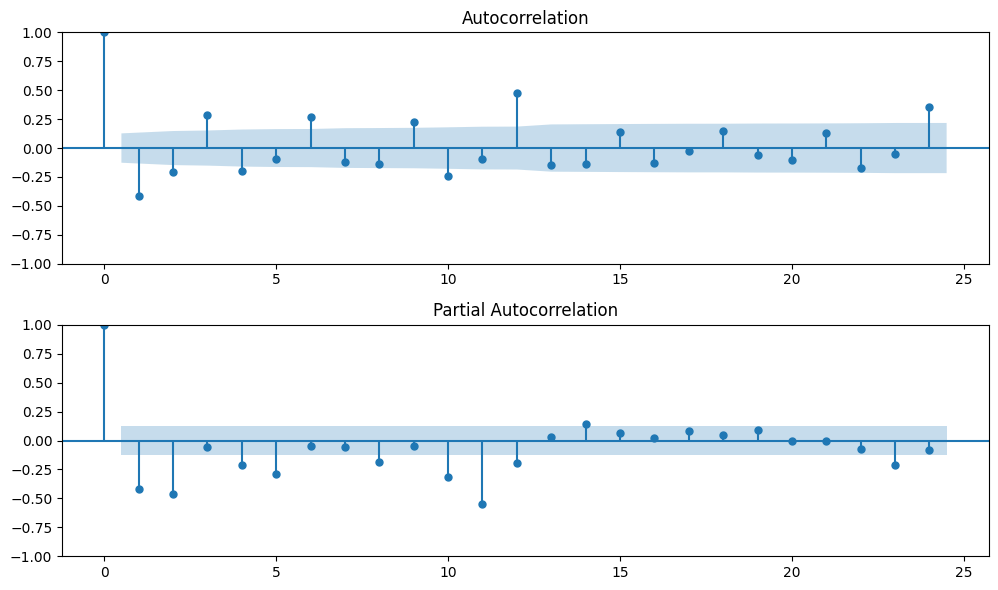

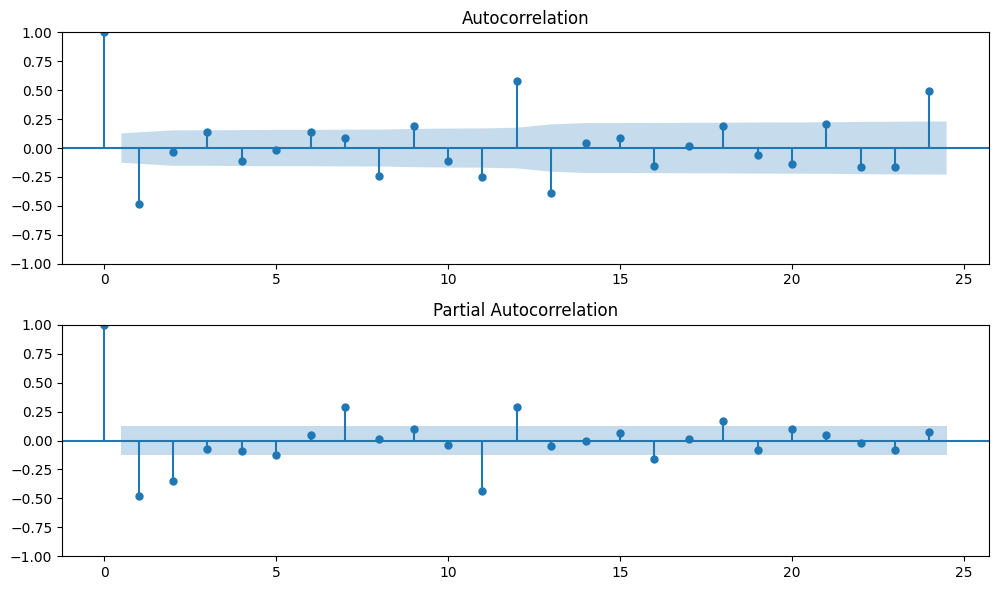

In [15]:
diff_tax_train = train["Tax Revenues"].diff().diff().dropna()
diff_BIR_train = train["BIR"].diff().diff().dropna()
diff_BOC_train = train["BOC"].diff().dropna()
diff_other_offices_train = train["Other Offices"].diff().dropna()
diff_expenditure_train = train["Expenditures"].diff().dropna()

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(diff_tax_train.dropna(), ax=ax[0])
plot_pacf(diff_tax_train.dropna(), ax=ax[1])
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(diff_BIR_train.dropna(), ax=ax[0])
plot_pacf(diff_BIR_train.dropna(), ax=ax[1])
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(diff_BOC_train.dropna(), ax=ax[0])
plot_pacf(diff_BOC_train.dropna(), ax=ax[1])
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(diff_other_offices_train.dropna(), ax=ax[0])
plot_pacf(diff_other_offices_train.dropna(), ax=ax[1])
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(diff_expenditure_train.dropna(), ax=ax[0])
plot_pacf(diff_expenditure_train.dropna(), ax=ax[1])
plt.tight_layout()
plt.show()


In [24]:

tax_train = train["Tax Revenues"]
bir_train = train["BIR"]
boc_train = train["BOC"]
others_train = train["Other Offices"]
expenditure_train = train["Expenditures"]
tax_test = test["Tax Revenues"]
bir_test = test["BIR"]
boc_test = test["BOC"]
others_test = test["Other Offices"]
expenditure_test = test["Expenditures"]

labels = LABEL_COLS

bounds_map = {
    "Tax Revenues":  {"p_min": 0, "p_max": 4, "d_min": 2, "d_max": 2, "q_min": 0, "q_max": 3, "P_min": 0, "P_max": 1, "D_min": 0, "D_max": 1, "Q_min": 0, "Q_max": 2},
    "BIR":           {"p_min": 0, "p_max": 4, "d_min": 2, "d_max": 2, "q_min": 0, "q_max": 3, "P_min": 0, "P_max": 1, "D_min": 0, "D_max": 1, "Q_min": 0, "Q_max": 2},
    "BOC":           {"p_min": 0, "p_max": 2, "d_min": 1, "d_max": 2, "q_min": 0, "q_max": 1, "P_min": 0, "P_max": 2, "D_min": 0, "D_max": 1, "Q_min": 0, "Q_max": 2},
    "Other Offices": {"p_min": 0, "p_max": 2, "d_min": 1, "d_max": 2, "q_min": 0, "q_max": 3, "P_min": 0, "P_max": 2, "D_min": 0, "D_max": 1, "Q_min": 0, "Q_max": 2},
    "Expenditures":  {"p_min": 0, "p_max": 2, "d_min": 1, "d_max": 2, "q_min": 0, "q_max": 1, "P_min": 0, "P_max": 2, "D_min": 0, "D_max": 1, "Q_min": 0, "Q_max": 1},
}

all_best_dfs = []
all_trial_dfs = []

# Use normalized datetime index to avoid alignment gaps in plots.
test_index = pd.to_datetime(test.index)
forecasts_df = pd.DataFrame(index=test_index)
fitted_models = {}

for label in labels:
    cfg = FEATURE_CONFIGS[label]
    exog_cols = cfg["features"] + cfg["dummy_vars"]
    available_cols = [c for c in exog_cols if c in feat_train.columns]

    macro_train = feat_train[available_cols]
    macro_test  = feat_test[available_cols]

    lbl_best, lbl_trials, lbl_forecasts, lbl_models = multitarget_sarima(
        train_df=train,
        test_df=test,
        exog_train=macro_train,
        exog_test=macro_test,
        labels=[label],
        bounds_map=bounds_map,
        seasonal_period=12,
        verbose=True,
        n_jobs=max(1, (os.cpu_count() or 2) - 1),
    )

    all_best_dfs.append(lbl_best)
    all_trial_dfs.append(lbl_trials)

    lbl_forecasts = lbl_forecasts.copy()
    lbl_forecasts.index = pd.to_datetime(lbl_forecasts.index)

    for col in lbl_forecasts.columns:
        aligned = lbl_forecasts[col].reindex(test_index)
        forecasts_df[col] = aligned.values

    fitted_models.update(lbl_models)

best_models_df = pd.concat(all_best_dfs)
all_trials_df = pd.concat(all_trial_dfs, ignore_index=True)

display(best_models_df)
display(forecasts_df.head())


[Tax Revenues] candidates: 240


Labels completed:   0%|          | 0/1 [00:00<?, ?it/s]

[Tax Revenues] progress: 50/240
[Tax Revenues] progress: 100/240
[Tax Revenues] progress: 150/240
[Tax Revenues] progress: 200/240


[Tax Revenues] done: 240/240, converged=240


[BIR] candidates: 240

...

Labels completed:   0%|          | 0/1 [00:00<?, ?it/s]

[Expenditures] progress: 50/144
[Expenditures] progress: 100/144


[Expenditures] done: 144/144, converged=144


,Best_Order,Best_Seasonal_Order,Best_AIC,MAE,RMSE,MAPE_pct
Target,,,,,,
Tax Revenues,"(3, 2, 3)","(0, 1, 2, 12)",4147.027875,60844.286909,69355.973200,25.815405
BIR,"(2, 2, 3)","(1, 1, 2, 12)",4093.790136,66671.525705,76460.900813,39.230406
BOC,"(0, 1, 1)","(1, 1, 2, 12)",3738.544411,5751.171376,7030.606627,8.686162
Other Offices,"(2, 1, 3)","(1, 1, 2, 12)",2791.582380,613.609794,780.196972,37.074034
Expenditures,"(2, 1, 0)","(2, 1, 0, 12)",4578.666240,159158.369169,175698.929362,39.298858


,Tax Revenues,BIR,BOC,Other Offices,Expenditures
Date,,,,,
2020-01-01,257294.307174,203800.342754,52282.261001,1843.364739,333219.228814
2020-02-01,211396.277573,165446.555827,45999.835931,2533.957541,357932.372293
2020-03-01,207980.597877,166911.072138,48497.632869,2119.007626,415050.304188
2020-04-01,279310.103565,243250.706163,36188.353490,1835.326435,304205.484642
2020-05-01,256513.920864,217637.420317,44221.773869,2535.264212,395000.935807


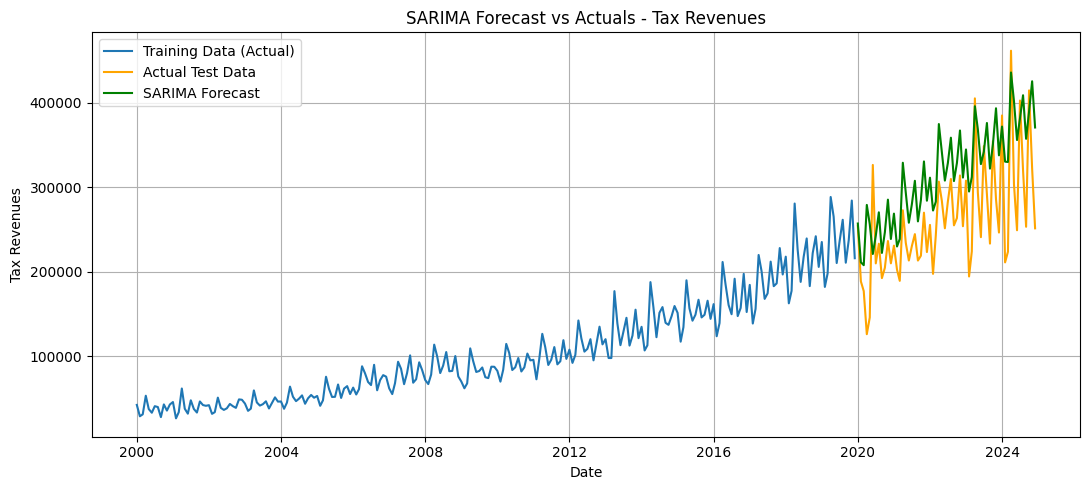

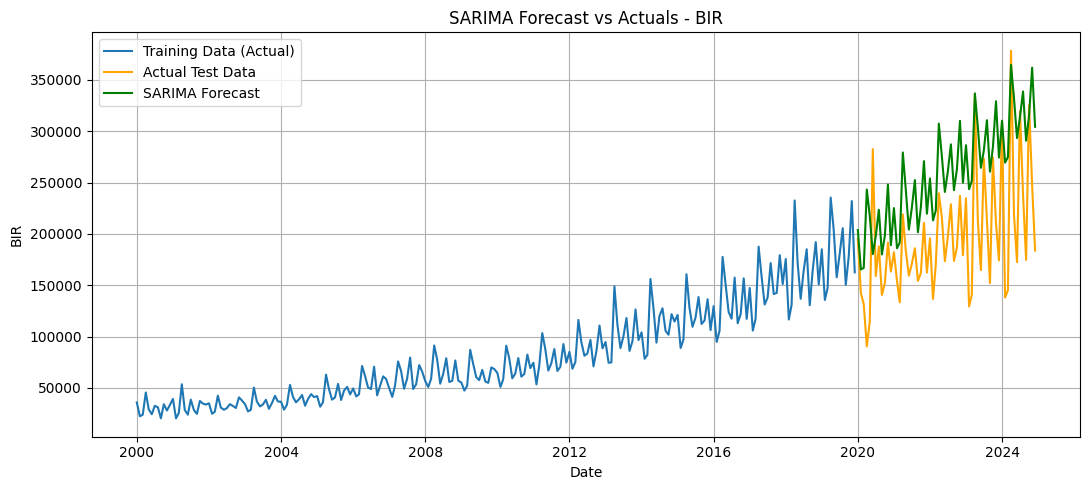

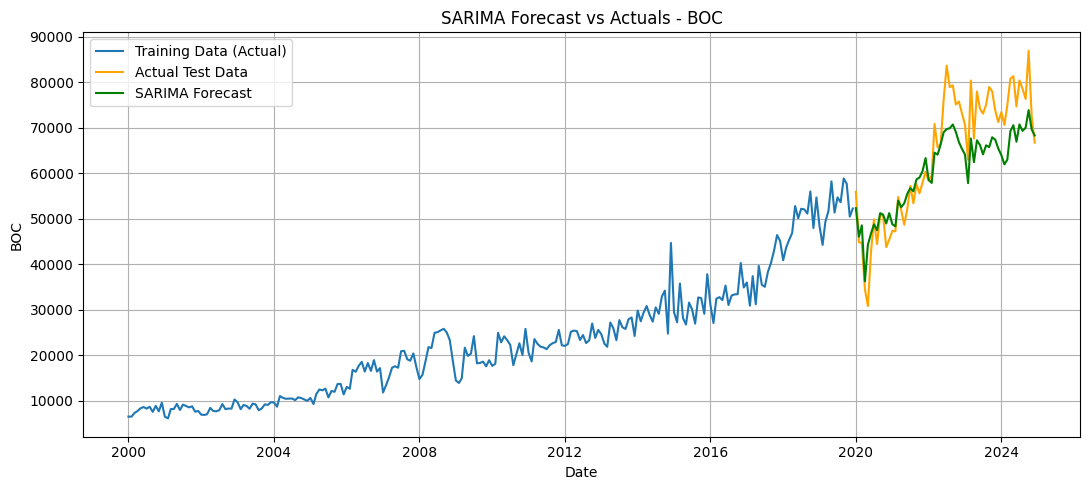

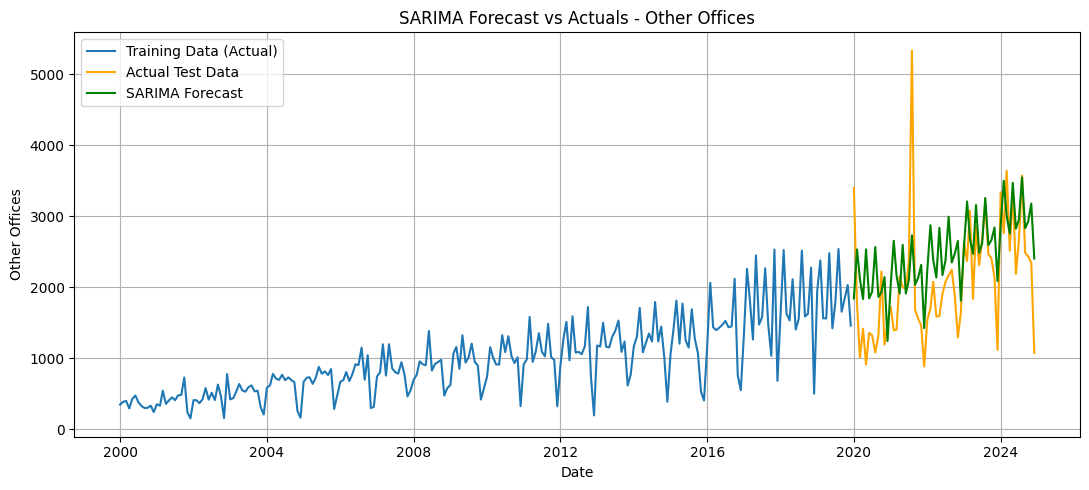

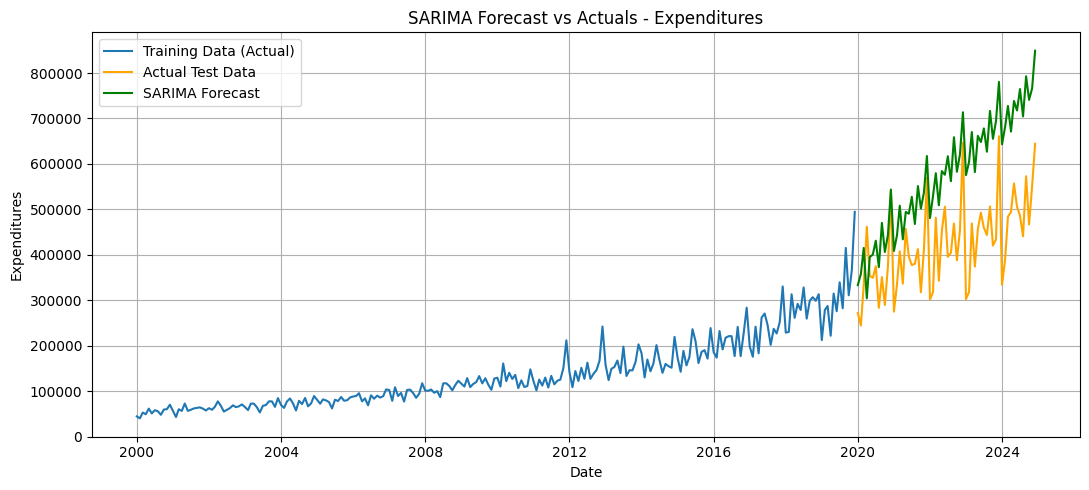

In [26]:
labels_to_plot = [lbl for lbl in labels if lbl in train.columns and lbl in test.columns and lbl in forecasts_df.columns]

if not labels_to_plot:
    raise ValueError("No matching labels found across train/test/forecasts_df.")

for lbl in labels_to_plot:
    plt.figure(figsize=(11, 5))
    plt.plot(train.index, train[lbl], label="Training Data (Actual)")
    plt.plot(test.index, test[lbl], label="Actual Test Data", color="orange")
    plt.plot(forecasts_df.index, forecasts_df[lbl], label="SARIMA Forecast", color="green")
    plt.title(f"SARIMA Forecast vs Actuals - {lbl}")
    plt.xlabel("Date")
    plt.ylabel(lbl)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [27]:
from pathlib import Path

labels = LABEL_COLS

# Load saved SARIMA predictions for the 2000 block.
results_dir = Path("results")
results_dir.mkdir(parents=True, exist_ok=True)

candidate_paths = [
    results_dir / "sarima_2000_forecasts.csv",
    results_dir / "sarimax_forecasts.csv",
]

pred_path = next((p for p in candidate_paths if p.exists()), None)

if pred_path is not None:
    preds_saved = pd.read_csv(pred_path)

    # Handle files saved with date index and files saved index=False.
    if "Date" in preds_saved.columns:
        preds_saved["Date"] = pd.to_datetime(preds_saved["Date"], errors="coerce")
        preds_saved = preds_saved.set_index("Date")
    elif preds_saved.shape[1] > 0 and preds_saved.columns[0].lower().startswith("unnamed"):
        idx = pd.to_datetime(preds_saved.iloc[:, 0], errors="coerce")
        preds_saved = preds_saved.iloc[:, 1:]
        preds_saved.index = idx
    elif len(preds_saved) == len(test):
        preds_saved.index = test.index
    else:
        raise ValueError(
            "Saved predictions have no usable date index and length does not match test horizon."
        )
elif "forecasts_df" in globals() and isinstance(forecasts_df, pd.DataFrame):
    pred_path = candidate_paths[0]
    forecasts_df.to_csv(pred_path)
    preds_saved = forecasts_df.copy()
else:
    raise FileNotFoundError(
        f"No saved predictions found in {results_dir}. Run the SARIMA forecasting cell first."
    )

# Keep only prediction columns that are known labels, then align to test index.
preds_saved = preds_saved[[c for c in preds_saved.columns if c in labels]]
preds_saved = preds_saved.reindex(test.index)

# Date-range evaluation window (inclusive): 2020-03-01 to 2022-06-01
start_date = pd.Timestamp("2020-03-01")
end_date = pd.Timestamp("2022-06-01")
period_mask = (test.index >= start_date) & (test.index <= end_date)
print(f"Rows in selected period: {int(period_mask.sum())}")

labels_to_eval = [
    lbl for lbl in labels
    if lbl in test.columns and lbl in preds_saved.columns
]

if not labels_to_eval:
    raise ValueError("No matching labels found across test and loaded predictions.")

rows = []
for lbl in labels_to_eval:
    actual = test[lbl].reindex(test.index)
    pred = preds_saved[lbl].reindex(test.index)

    valid = period_mask & actual.notna() & pred.notna()
    n_period = int(valid.sum())

    if n_period == 0:
        rows.append({"Label": lbl, "N_period": 0, "MAE": np.nan, "RMSE": np.nan, "MAPE": np.nan})
        continue

    y_true = actual[valid].values
    y_pred = pred[valid].values

    eps = 1e-8
    mae = float(np.mean(np.abs(y_true - y_pred)))
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    mape = float(np.mean(np.abs((y_true - y_pred) / (y_true + eps))) * 100)

    rows.append({
        "Label": lbl,
        "N_period": n_period,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
    })

period_eval_df = pd.DataFrame(rows)
display(period_eval_df)
print(f"Predictions loaded from: {pred_path}")
print(f"Evaluation window: {start_date.date()} to {end_date.date()}")


Rows in selected period: 28


,Label,N_period,MAE,RMSE,MAPE
0,Tax Revenues,28,56884.187266,62967.125622,27.160269
1,BIR,28,59495.504994,64595.047777,37.790382
2,BOC,28,2905.194411,4047.913983,6.209934
3,Other Offices,28,728.676566,907.136950,49.418747
4,Expenditures,28,105275.497295,116005.072945,29.373383


Predictions loaded from: results\sarima_2000_forecasts.csv
Evaluation window: 2020-03-01 to 2022-06-01


In [28]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera

# 2000 residual diagnostics on test horizon (SARIMAX predictions)
if "preds_saved" not in globals():
    raise ValueError("Run the 2000 prediction-loading cell first so preds_saved is available.")

diag_rows = []
for lbl in LABEL_COLS:
    if lbl not in test.columns or lbl not in preds_saved.columns:
        continue

    y_true = test[lbl].reindex(test.index)
    y_pred = preds_saved[lbl].reindex(test.index)

    valid = y_true.notna() & y_pred.notna()
    if valid.sum() < 10:
        diag_rows.append({
            "Label": lbl,
            "N": int(valid.sum()),
            "LB_stat_lag10": np.nan,
            "LB_pvalue_lag10": np.nan,
            "JB_stat": np.nan,
            "JB_pvalue": np.nan,
            "Skew": np.nan,
            "Kurtosis": np.nan,
            "LB_white_noise_5pct": np.nan,
            "JB_normal_5pct": np.nan,
        })
        continue

    resid = (y_true[valid] - y_pred[valid]).values

    lb = acorr_ljungbox(resid, lags=[10], return_df=True)
    jb_stat, jb_p, jb_skew, jb_kurt = jarque_bera(resid)

    lb_stat = float(lb["lb_stat"].iloc[0])
    lb_p = float(lb["lb_pvalue"].iloc[0])

    diag_rows.append({
        "Label": lbl,
        "N": int(valid.sum()),
        "LB_stat_lag10": lb_stat,
        "LB_pvalue_lag10": lb_p,
        "JB_stat": float(jb_stat),
        "JB_pvalue": float(jb_p),
        "Skew": float(jb_skew),
        "Kurtosis": float(jb_kurt),
        "LB_white_noise_5pct": bool(lb_p > 0.05),
        "JB_normal_5pct": bool(jb_p > 0.05),
    })

residual_diag_2000 = pd.DataFrame(diag_rows)
display(residual_diag_2000)


,Label,N,LB_stat_lag10,LB_pvalue_lag10,JB_stat,JB_pvalue,Skew,Kurtosis,LB_white_noise_5pct,JB_normal_5pct
0,Tax Revenues,60,60.740543,2.624075e-09,12.627761,1.810992e-03,0.758465,4.658321,False,False
1,BIR,60,57.650907,1.005671e-08,11.177685,3.739354e-03,0.697397,4.589221,False,False
2,BOC,60,224.059922,1.509300e-42,1.671667,4.335131e-01,-0.236685,2.333226,False,True
3,Other Offices,60,4.025617,9.461840e-01,89.010075,4.695781e-20,1.547892,8.100995,True,False
4,Expenditures,60,127.540867,1.481775e-22,8.744990,1.261971e-02,0.661523,4.321949,False,False
